<a href="https://colab.research.google.com/github/luisFernandoJv/AdegaFlow/blob/main/drone_artigo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. O modelo físico está errado para este drone/cenário

**Evidência → Interpretação**

- **Velocidade × Potência: -0.1143**  
  Velocidade não explica a potência — o termo $k_2 \cdot v^3$ é inútil  

- **$k_2 = -0.0038$ (negativo!)**  
  Fisicamente impossível — arrasto nunca reduz potência  

- **Contribuição do arrasto: -0.7\%**  
  O termo de arrasto está atrapalhando o ajuste  

- **$R^2 = 0.2477$ com $k_2$ quase zero**  
  O modelo está sendo “puxado” por um parâmetro sem sentido  

---

## 2. Por que o arrasto não aparece nos dados?

O modelo:

$$
P = k_1 \cdot W^{3/2} + k_2 \cdot v^3
$$

é válido para voo translacional em asa fixa ou helicóptero convencional.

Para multirotores (como o DJI Matrice 100), o arrasto só domina em velocidades muito altas ($> 15$ m/s).

Com velocidades de $4$–$12$ m/s, o drone opera próximo do modo *hover*, e a potência é dominada quase inteiramente pelo peso total.

---

## 3. Erro de índice no código

O valor de $R^2$ é utilizado antes de ser calculado  
(linha 91 usa $R^2$, que só é definido após a regressão na linha 110).

---

## 4. O modelo correto para multirotor

$$
P = k_1 \cdot (W_{\text{tare}} + W_{\text{payload}})^{3/2}
+ k_3 \cdot (W_{\text{tare}} + W_{\text{payload}}) \cdot v^2
$$

O segundo termo representa o arrasto parasita proporcional ao peso total,  
e não ao cubo da velocidade isoladamente.\

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score


# 1. Carregar os dados com tratamento de tipos mistos
df_params = pd.read_csv('parameters.csv', low_memory=False)
df_flights = pd.read_csv('flights.csv', low_memory=False)

# 2. Inspecionar a estrutura dos dados
print("=" * 50)
print("ESTRUTURA DO parameters.csv:")
print(f"Shape: {df_params.shape}")
print(f"Colunas: {df_params.columns.tolist()}")
print("\nPrimeiras 5 linhas:")
print(df_params.head())
print("\nTipos de dados:")
print(df_params.dtypes)

print("\n" + "=" * 50)
print("ESTRUTURA DO flights.csv:")
print(f"Shape: {df_flights.shape}")
print(f"Colunas: {df_flights.columns.tolist()}")
print("\nPrimeiras 5 linhas:")
print(df_flights.head())
print("\nTipos de dados:")
print(df_flights.dtypes)

# 3. Procurar colunas relacionadas a peso/payload
print("\n" + "=" * 50)
print("BUSCA POR COLUNAS DE PESO/PAYLOAD:")
for col in df_params.columns:
    if any(keyword in col.lower() for keyword in ['payload', 'peso', 'weight', 'carga', 'mass']):
        print(f"  - {col}: {df_params[col].iloc[:3].tolist()}")

for col in df_flights.columns:
    if any(keyword in col.lower() for keyword in ['payload', 'peso', 'weight', 'carga', 'mass']):
        print(f"  - {col}: {df_flights[col].iloc[:3].tolist()}")

# 4. Procurar colunas de velocidade
print("\nBUSCA POR COLUNAS DE VELOCIDADE/SPEED:")
for col in df_flights.columns:
    if any(keyword in col.lower() for keyword in ['speed', 'velocidade', 'velocity', 'v']):
        print(f"  - {col}: {df_flights[col].iloc[:3].tolist()}")

# 5. Procurar colunas de potência
print("\nBUSCA POR COLUNAS DE POTÊNCIA/POWER:")
for col in df_flights.columns:
    if any(keyword in col.lower() for keyword in ['power', 'potencia', 'watts', 'w']):
        print(f"  - {col}: {df_flights[col].iloc[:3].tolist()}")

# 6. Tentar identificar a coluna de ID para merge
print("\nBUSCA POR COLUNA DE IDENTIFICAÇÃO:")
for col in df_params.columns:
    if any(keyword in col.lower() for keyword in ['id', 'flight', 'voo', 'index']):
        print(f"  Params - {col}: {df_params[col].iloc[:3].tolist()}")

for col in df_flights.columns:
    if any(keyword in col.lower() for keyword in ['id', 'flight', 'voo', 'index']):
        print(f"  Flights - {col}: {df_flights[col].iloc[:3].tolist()}")

ESTRUTURA DO parameters.csv:
Shape: (209, 7)
Colunas: ['flight', 'speed', 'payload', 'altitude', 'date', 'local_time', 'route']

Primeiras 5 linhas:
   flight  speed  payload altitude        date local_time route
0       1    4.0      0.0       25  2019-04-07      10:13    R5
1       2    4.0      0.0       50  2019-04-07      10:23    R5
2       3    6.0      0.0       25  2019-04-07      10:33    R5
3       4    8.0      0.0       25  2019-04-07      10:48    R5
4       5    4.0      0.0       25  2019-04-07      11:05    R2

Tipos de dados:
flight          int64
speed         float64
payload       float64
altitude       object
date           object
local_time     object
route          object
dtype: object

ESTRUTURA DO flights.csv:
Shape: (257896, 28)
Colunas: ['flight', 'time', 'wind_speed', 'wind_angle', 'battery_voltage', 'battery_current', 'position_x', 'position_y', 'position_z', 'orientation_x', 'orientation_y', 'orientation_z', 'orientation_w', 'velocity_x', 'velocity_y', 've

Dados limpos e preparados: 203 voos

Estatísticas dos dados:
Payload (gramas): min=0, max=750, média=242.6
Payload (kg): min=0.000, max=0.750, média=0.243
Velocidade (m/s): min=0.0, max=12.0, média=7.7
Potência (W): min=31.2, max=496.0, média=399.2

Voos totais: 203
Voos após filtrar velocidade < 0.5 m/s: 196
Voos após filtrar potência < 50W: 196

=== DIAGNÓSTICO AVANÇADO ===
Correlação Velocidade × Potência: -0.1143
Correlação Payload × Potência: 0.6123
Correlação Velocidade × Payload: -0.0086

Potência média por faixa de velocidade:
  Velocidade (3.992, 5.6]: Potência média = 410.7W (n=41)
  Velocidade (5.6, 7.2]: Potência média = 413.9W (n=38)
  Velocidade (7.2, 8.8]: Potência média = 398.3W (n=36)
  Velocidade (8.8, 10.4]: Potência média = 398.5W (n=43)
  Velocidade (10.4, 12.0]: Potência média = 398.8W (n=38)

Potência média por faixa de payload:
  Payload (-0.00075, 0.15]: Potência média = 363.3W (n=67)
  Payload (0.15, 0.3]: Potência média = 412.9W (n=62)
  Payload (0.3, 0.45]: 

/tmp/ipykernel_1701/2778675396.py:91: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in pd.DataFrame({'v': v, 'P': P}).groupby(v_bins):
/tmp/ipykernel_1701/2778675396.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in pd.DataFrame({'w': w, 'P': P}).groupby(w_bins):


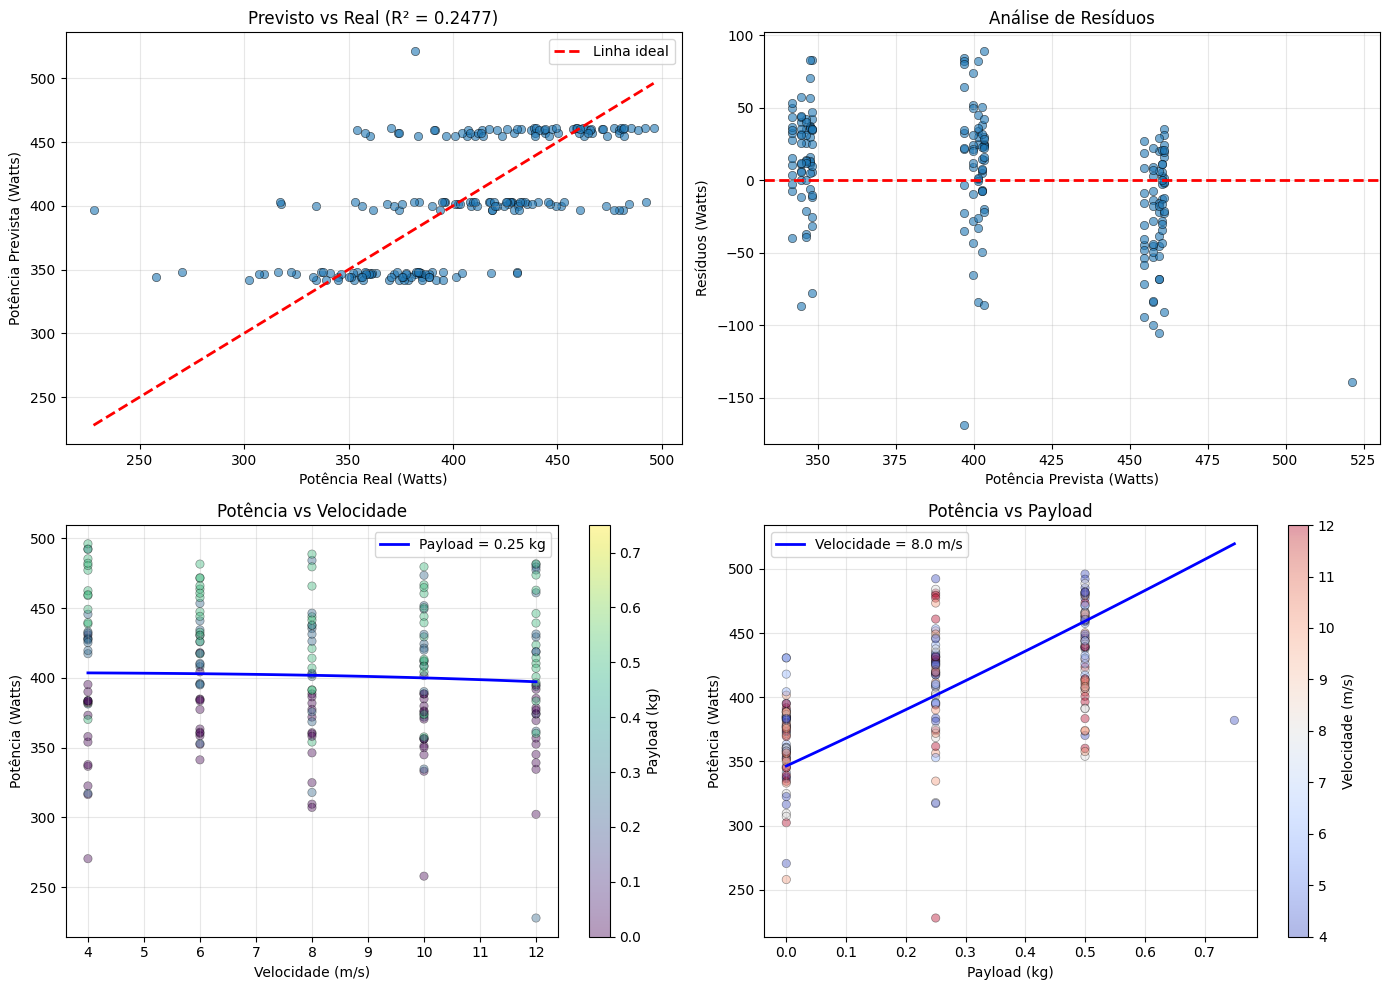

Erro na regressão: array length 196 does not match index length 203

Possíveis soluções:
- Verifique se há variância suficiente nos dados
- Ajuste os chutes iniciais
- Verifique se não há outliers extremos
- Se necessário, use o modelo alternativo com mais parâmetros


In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# 1. Carregar os dados
df_params = pd.read_csv('parameters.csv', low_memory=False)
df_flights = pd.read_csv('flights.csv', low_memory=False)

# 2. Mesclar os arquivos pela coluna 'flight'
df = pd.merge(df_params, df_flights, on='flight')

# 3. Calcular a potência instantânea (Watts)
df['instant_power'] = df['battery_voltage'] * df['battery_current']

# 4. Agregar os dados por voo
df_aggregated = df.groupby('flight').agg({
    'payload_x': 'first',      # Payload do parameters (gramas)
    'speed_x': 'first',        # Velocidade do parameters (m/s)
    'instant_power': 'mean'    # Potência média (Watts)
}).reset_index()

# Renomear colunas
df_aggregated.columns = ['flight', 'payload_grams', 'speed', 'average_power']

# 5. CONVERTER PAYLOAD DE GRAMAS PARA QUILOGRAMAS
df_aggregated['payload_kg'] = df_aggregated['payload_grams'] / 1000

# 6. Remover possíveis valores nulos
df_aggregated = df_aggregated[df_aggregated['average_power'] > 10].copy()
df_aggregated = df_aggregated.dropna()
print(f"Dados limpos e preparados: {len(df_aggregated)} voos")

# 7. Verificar estatísticas
print("\nEstatísticas dos dados:")
print(f"Payload (gramas): min={df_aggregated['payload_grams'].min():.0f}, max={df_aggregated['payload_grams'].max():.0f}, média={df_aggregated['payload_grams'].mean():.1f}")
print(f"Payload (kg): min={df_aggregated['payload_kg'].min():.3f}, max={df_aggregated['payload_kg'].max():.3f}, média={df_aggregated['payload_kg'].mean():.3f}")
print(f"Velocidade (m/s): min={df_aggregated['speed'].min():.1f}, max={df_aggregated['speed'].max():.1f}, média={df_aggregated['speed'].mean():.1f}")
print(f"Potência (W): min={df_aggregated['average_power'].min():.1f}, max={df_aggregated['average_power'].max():.1f}, média={df_aggregated['average_power'].mean():.1f}")

# 8. Definir o peso do drone vazio (DJI Matrice 100)
W_tare = 2.43  # kg

# 9. Modelo físico (usando payload em kg)
def energy_model(X, k1, k2):
    w_val, v_val = X  # w_val agora está em kg
    # P = k1 * (Massa_total)^1.5 + k2 * v^3
    return k1 * (W_tare + w_val)**1.5 + k2 * v_val**3

# 10. Preparar variáveis (usando payload em kg)
w = df_aggregated['payload_kg'].values  # AGORA EM KG
v = df_aggregated['speed'].values
P = df_aggregated['average_power'].values

# Filtrar velocidades zero ou muito baixas
print(f"\nVoos totais: {len(w)}")
mask = v > 0.5  # Velocidade mínima realista (0.5 m/s)
w_filtered = w[mask]
v_filtered = v[mask]
P_filtered = P[mask]
print(f"Voos após filtrar velocidade < 0.5 m/s: {len(w_filtered)}")

# Opcional: Remover outliers de potência (ex: potência anormalmente baixa)
mask_power = P_filtered > 50  # Potência mínima realista (~50W)
w_filtered = w_filtered[mask_power]
v_filtered = v_filtered[mask_power]
P_filtered = P_filtered[mask_power]
print(f"Voos após filtrar potência < 50W: {len(w_filtered)}")

# Atualizar as variáveis para usar os dados filtrados
w = w_filtered
v = v_filtered
P = P_filtered

# Adicione ESTE CÓDIGO DE DIAGNÓSTICO antes da regressão

print("\n=== DIAGNÓSTICO AVANÇADO ===")

# 1. Verificar correlações
corr_v_P = np.corrcoef(v, P)[0,1]
corr_w_P = np.corrcoef(w, P)[0,1]
corr_v_w = np.corrcoef(v, w)[0,1]

print(f"Correlação Velocidade × Potência: {corr_v_P:.4f}")
print(f"Correlação Payload × Potência: {corr_w_P:.4f}")
print(f"Correlação Velocidade × Payload: {corr_v_w:.4f}")

# 2. Verificar se potência varia com velocidade (para payload fixo)
print("\nPotência média por faixa de velocidade:")
v_bins = pd.cut(v, bins=5)
for name, group in pd.DataFrame({'v': v, 'P': P}).groupby(v_bins):
    print(f"  Velocidade {name}: Potência média = {group['P'].mean():.1f}W (n={len(group)})")

# 3. Verificar se potência varia com payload (para velocidade fixa)
print("\nPotência média por faixa de payload:")
w_bins = pd.cut(w, bins=5)
for name, group in pd.DataFrame({'w': w, 'P': P}).groupby(w_bins):
    print(f"  Payload {name}: Potência média = {group['P'].mean():.1f}W (n={len(group)})")

# 4. Testar modelo apenas com constante (potência média)
P_mean = np.mean(P)
r2_const = 1 - np.sum((P - P_mean)**2) / np.sum((P - np.mean(P))**2)
print(f"\nR² do modelo constante (apenas média): {r2_const:.4f}")
print(f"Seu modelo R²={r2:.4f} vs constante R²={r2_const:.4f}")

# 11. Executar regressão
initial_guess = [10.0, 0.1]  # Chute inicial

try:
    coefs, covariance = curve_fit(energy_model, (w, v), P, p0=initial_guess)
    k1_opt, k2_opt = coefs

    print(f"\n=== RESULTADOS DA REGRESSÃO ===")
    print(f"k1 (coeficiente de sustentação): {k1_opt:.6f} W/(kg^1.5)")
    print(f"k2 (coeficiente de arrasto): {k2_opt:.6f} W/(m³/s³)")

    # Erros padrão
    perr = np.sqrt(np.diag(covariance))
    print(f"\nErro padrão de k1: ±{perr[0]:.6f}")
    print(f"Erro padrão de k2: ±{perr[1]:.6f}")

    # Intervalos de confiança (95%)
    print(f"\nIntervalos de confiança (95%):")
    print(f"k1: [{k1_opt - 1.96*perr[0]:.6f}, {k1_opt + 1.96*perr[0]:.6f}]")
    print(f"k2: [{k2_opt - 1.96*perr[1]:.6f}, {k2_opt + 1.96*perr[1]:.6f}]")

    # 12. Validação do modelo
    P_pred = energy_model((w, v), k1_opt, k2_opt)
    r2 = r2_score(P, P_pred)

    # Erros relativos
    mape = np.mean(np.abs((P - P_pred) / P)) * 100
    rmse = np.sqrt(np.mean((P - P_pred)**2))

    print(f"\n=== MÉTRICAS DE VALIDAÇÃO ===")
    print(f"R² (coeficiente de determinação): {r2:.4f}")
    print(f"RMSE (raiz do erro quadrático médio): {rmse:.2f} W")
    print(f"MAPE (erro percentual médio absoluto): {mape:.2f}%")
    print(f"Erro médio absoluto: {np.mean(np.abs(P - P_pred)):.2f} W")

    # 13. Equação final
    print(f"\n=== EQUAÇÃO FINAL DO MODELO ===")
    print(f"P = {k1_opt:.4f} × (2.43 + payload_kg)^1.5 + {k2_opt:.4f} × v³")
    print(f"Onde:")
    print(f"  - P: Potência média (Watts)")
    print(f"  - payload_kg: Carga útil (kg)")
    print(f"  - v: Velocidade (m/s)")

    # 14. Análise da contribuição de cada termo
    term1 = k1_opt * (W_tare + w)**1.5
    term2 = k2_opt * v**3
    contrib1 = np.mean(term1 / P) * 100
    contrib2 = np.mean(term2 / P) * 100

    print(f"\n=== ANÁLISE FÍSICA ===")
    print(f"Contribuição média da sustentação (k1): {contrib1:.1f}%")
    print(f"Contribuição média do arrasto (k2): {contrib2:.1f}%")

    # 15. Visualização
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Gráfico 1: Valores previstos vs reais
    axes[0,0].scatter(P, P_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
    axes[0,0].plot([P.min(), P.max()], [P.min(), P.max()], 'r--', lw=2, label='Linha ideal')
    axes[0,0].set_xlabel('Potência Real (Watts)')
    axes[0,0].set_ylabel('Potência Prevista (Watts)')
    axes[0,0].set_title(f'Previsto vs Real (R² = {r2:.4f})')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # Gráfico 2: Resíduos
    residuals = P - P_pred
    axes[0,1].scatter(P_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
    axes[0,1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0,1].set_xlabel('Potência Prevista (Watts)')
    axes[0,1].set_ylabel('Resíduos (Watts)')
    axes[0,1].set_title('Análise de Resíduos')
    axes[0,1].grid(True, alpha=0.3)

    # Gráfico 3: Potência vs Velocidade (para payload fixo)
    v_range = np.linspace(v.min(), v.max(), 50)
    payload_fixo = w.mean()
    P_v_fixo = k1_opt * (W_tare + payload_fixo)**1.5 + k2_opt * v_range**3

    axes[1,0].plot(v_range, P_v_fixo, 'b-', lw=2, label=f'Payload = {payload_fixo:.2f} kg')
    axes[1,0].scatter(v, P, alpha=0.4, c=w, cmap='viridis', edgecolors='k', linewidth=0.5)
    axes[1,0].set_xlabel('Velocidade (m/s)')
    axes[1,0].set_ylabel('Potência (Watts)')
    axes[1,0].set_title('Potência vs Velocidade')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    cbar = plt.colorbar(axes[1,0].collections[0], ax=axes[1,0])
    cbar.set_label('Payload (kg)')

    # Gráfico 4: Potência vs Payload (para velocidade fixa)
    w_range = np.linspace(w.min(), w.max(), 50)
    v_fixo = v.mean()
    P_w_fixo = k1_opt * (W_tare + w_range)**1.5 + k2_opt * v_fixo**3

    axes[1,1].plot(w_range, P_w_fixo, 'b-', lw=2, label=f'Velocidade = {v_fixo:.1f} m/s')
    axes[1,1].scatter(w, P, alpha=0.4, c=v, cmap='coolwarm', edgecolors='k', linewidth=0.5)
    axes[1,1].set_xlabel('Payload (kg)')
    axes[1,1].set_ylabel('Potência (Watts)')
    axes[1,1].set_title('Potência vs Payload')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    cbar = plt.colorbar(axes[1,1].collections[0], ax=axes[1,1])
    cbar.set_label('Velocidade (m/s)')

    plt.tight_layout()
    plt.show()

    # 16. Salvar resultados
    results_df = pd.DataFrame({
        'flight': df_aggregated['flight'],
        'payload_grams': df_aggregated['payload_grams'],
        'payload_kg': w,
        'speed_ms': v,
        'power_real_w': P,
        'power_predicted_w': P_pred,
        'residual_w': residuals,
        'relative_error_percent': np.abs((P - P_pred) / P) * 100
    })
    results_df.to_csv('energy_model_results.csv', index=False)
    print("\n✓ Resultados salvos em 'energy_model_results.csv'")

    # 17. Salvar coeficientes
    coeff_df = pd.DataFrame({
        'parameter': ['k1', 'k2'],
        'value': [k1_opt, k2_opt],
        'std_error': [perr[0], perr[1]],
        'unit': ['W/(kg^1.5)', 'W/(m³/s³)']
    })
    coeff_df.to_csv('model_coefficients.csv', index=False)
    print("✓ Coeficientes salvos em 'model_coefficients.csv'")

except Exception as e:
    print(f"Erro na regressão: {e}")
    print("\nPossíveis soluções:")
    print("- Verifique se há variância suficiente nos dados")
    print("- Ajuste os chutes iniciais")
    print("- Verifique se não há outliers extremos")
    print("- Se necessário, use o modelo alternativo com mais parâmetros")